<a href="https://colab.research.google.com/github/MaggieAngel04/MachineLearning/blob/main/MAmachinelearningPHISHING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
URLlink = "https://raw.githubusercontent.com/MaggieAngel04/MachineLearning/refs/heads/main/PhiUSIIL_Phishing_URL_Dataset.csv"
df = pd.read_csv(URLlink)
df.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


# Exploring dataset:

In [ ]:
print(df.describe)

<bound method NDFrame.describe of            FILENAME                                                URL  \
0        521848.txt                   https://www.southbankmosaics.com   
1         31372.txt                           https://www.uni-mainz.de   
2        597387.txt                     https://www.voicefmradio.co.uk   
3        554095.txt                        https://www.sfnmjournal.com   
4        151578.txt                 https://www.rewildingargentina.org   
...             ...                                                ...   
235790   660997.txt                     https://www.skincareliving.com   
235791    77185.txt                      https://www.winchester.gov.uk   
235792   622132.txt                    https://www.nononsensedesign.be   
235793  7503962.txt  https://patient-cell-40f5.updatedlogmylogin.wo...   
235794   384822.txt                 https://www.alternativefinland.com   

        URLLength                                           Domain  \
0      

In [ ]:
print(df.shape)

(235795, 56)


In [ ]:
df.dtypes.value_counts()

,count
int64,41
float64,10
object,5


In [ ]:
df.dtypes

,0
FILENAME,object
URL,object
URLLength,int64
Domain,object
DomainLength,int64
IsDomainIP,int64
TLD,object
URLSimilarityIndex,float64
CharContinuationRate,float64
TLDLegitimateProb,float64


In [ ]:
df.isnull().sum()

,0
FILENAME,0
URL,0
URLLength,0
Domain,0
DomainLength,0
IsDomainIP,0
TLD,0
URLSimilarityIndex,0
CharContinuationRate,0
TLDLegitimateProb,0


In [ ]:
df['label'].value_counts()

,count
label,
1,134850
0,100945


Text(0, 0.5, 'number')

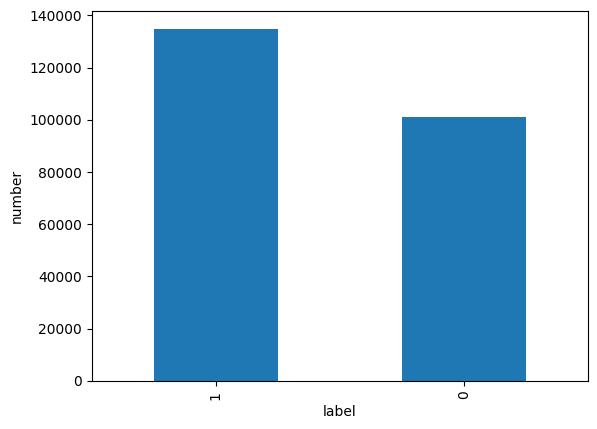

In [ ]:
import matplotlib.pyplot as plt
df['label'].value_counts().plot(kind='bar')
plt.xlabel('label')
plt.ylabel('number')


# Implementation:

# Preprocessing:

In [ ]:
df = df.drop(["FILENAME", "URL","Domain","TLD", "Title"], axis=1)


In [ ]:
df.dtypes

,0
URLLength,int64
DomainLength,int64
IsDomainIP,int64
URLSimilarityIndex,float64
CharContinuationRate,float64
TLDLegitimateProb,float64
URLCharProb,float64
TLDLength,int64
NoOfSubDomain,int64
HasObfuscation,int64


In [ ]:
df = df.drop_duplicates()

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("label", axis=1)
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
trainnumber = y_train.value_counts()
testnumber = y_test.value_counts()
table = pd.concat([trainnumber, testnumber], axis=1)
table.columns = ['Training', 'Testing']
print(table)

       Training  Testing
label                   
1         94474    40376
0         70016    30121


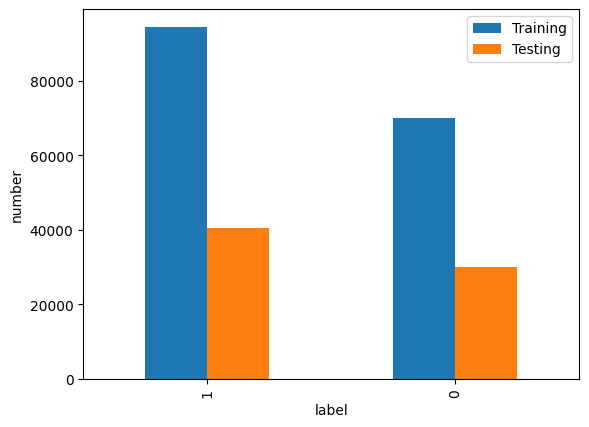

In [ ]:
import matplotlib.pyplot as plt
table.plot(kind='bar')
plt.xlabel('label')
plt.ylabel('number')
plt.show()


In [ ]:
import pandas as pd

train_df= pd.DataFrame(X_train)
test_df= pd.DataFrame(X_test)
overlap= pd.merge(train_df, test_df, how='inner')

print(len(overlap))
#originally showed 1251, now shows 0 yay
#KNN somehow performs better now... more models at 100% :(

0


In [ ]:
print(df.shape)

(234987, 51)


In [ ]:
#undersample the 1 label
#after split to avoid data leak
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(sampling_strategy='majority', random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)
print(y_train_res.value_counts())

#X_test_res, y_test_res = rus.fit_resample(X_test, y_test)
#print(y_test_res.value_counts())

label
0    70016
1    70016
Name: count, dtype: int64


In [ ]:
resampled_train_counts = y_train_res.value_counts()
#resampled_test_counts = y_test_res.value_counts()
#table = pd.concat([resampled_train_counts, resampled_test_counts], axis=1)
table = pd.concat([resampled_train_counts, testnumber], axis=1)
table.columns = ['Training', 'Testing']
print(table)

       Training  Testing
label                   
0         70016    30121
1         70016    40376


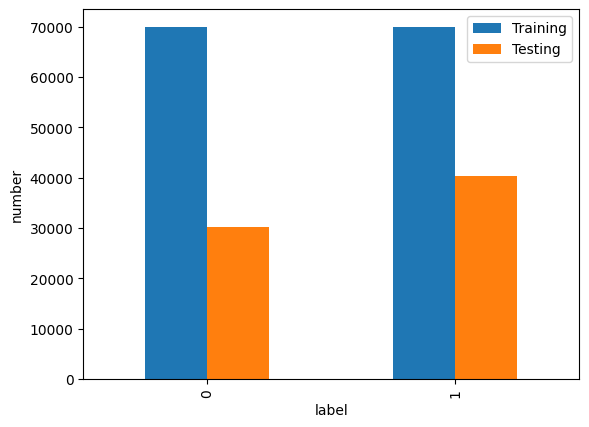

In [ ]:
import matplotlib.pyplot as plt
table.plot(kind='bar')
plt.xlabel('label')
plt.ylabel('number')
plt.show()

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
RF= RandomForestClassifier(random_state=42)
RF.fit(X_train_res, y_train_res)

RandomForestClassifier(random_state=42)

In [ ]:
ypredict = RF.predict(X_test)

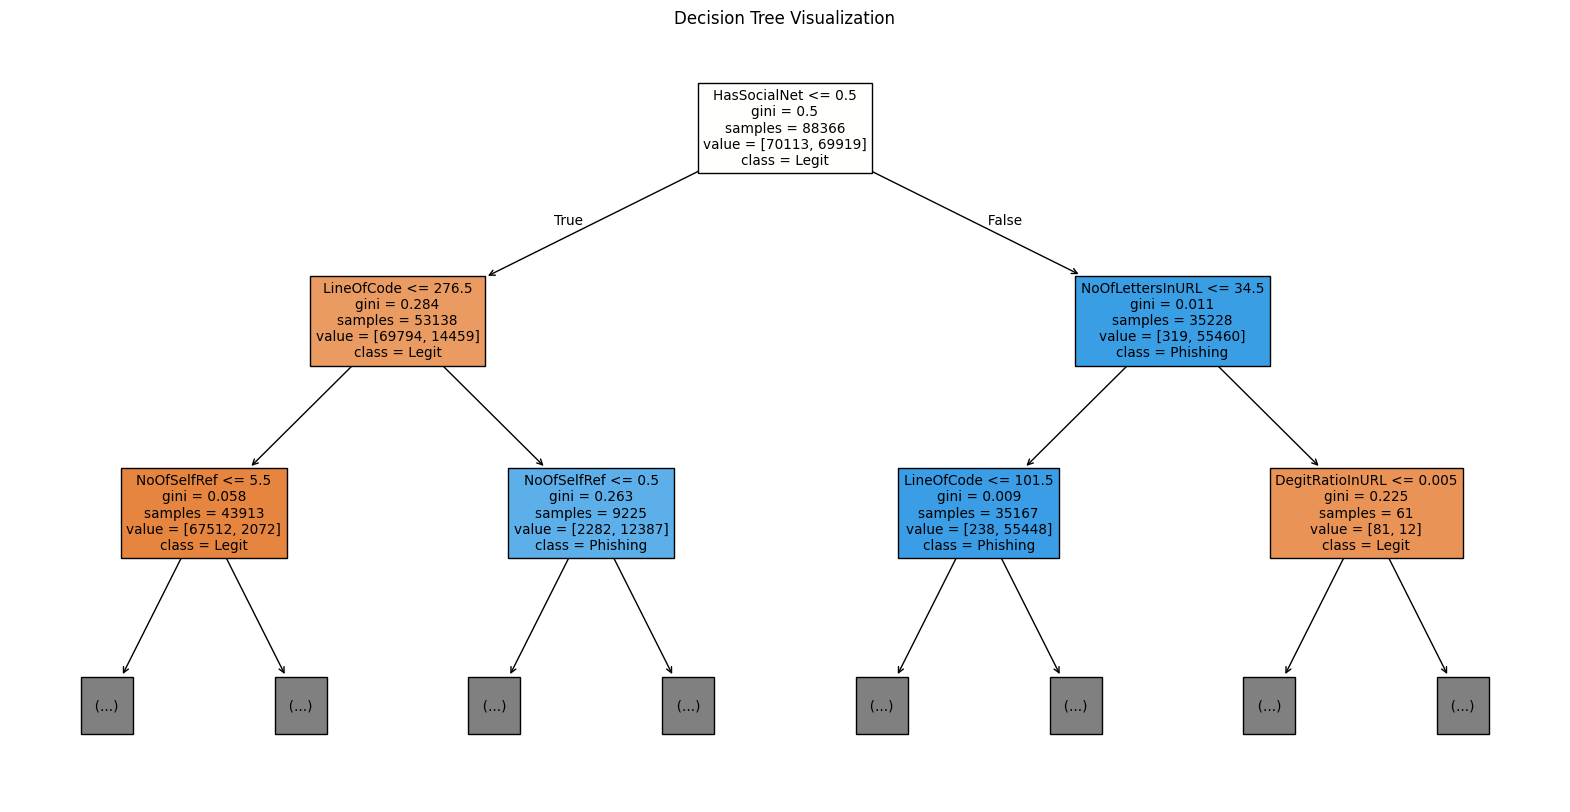

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(RF.estimators_[0], feature_names=X.columns, class_names=["Legit", "Phishing"], filled=True, max_depth=2)
plt.title("Decision Tree Visualization")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, ypredict, digits=5))

              precision    recall  f1-score   support

           0    1.00000   1.00000   1.00000     30121
           1    1.00000   1.00000   1.00000     40376

    accuracy                        1.00000     70497
   macro avg    1.00000   1.00000   1.00000     70497
weighted avg    1.00000   1.00000   1.00000     70497



In [ ]:
(y_test == ypredict).sum()
#see how well it predicts a bit closer, is actually 100%

np.int64(70497)

In [ ]:
corrilation = df.corr(numeric_only=True)['label'].sort_values(ascending=False)
print(corrilation.head(10))
#shows the corrilation between columns.

label                    1.000000
URLSimilarityIndex       0.859856
HasSocialNet             0.783543
HasCopyrightInfo         0.742593
HasDescription           0.689297
IsHTTPS                  0.612415
DomainTitleMatchScore    0.583288
HasSubmitButton          0.577442
IsResponsive             0.552127
URLTitleMatchScore       0.537578
Name: label, dtype: float64


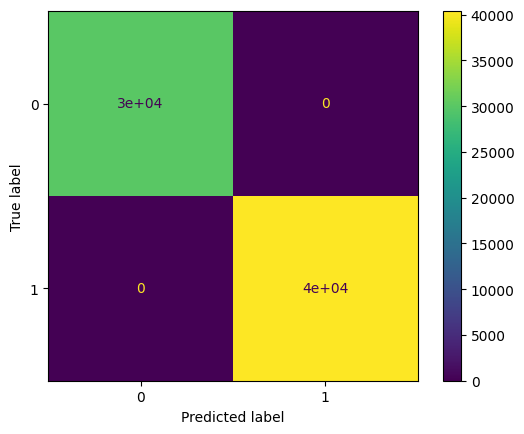

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, ypredict)
plt.show()
# 0= legitimate        1= phishing

In [ ]:
from sklearn.model_selection import cross_val_score

scoresRF = cross_val_score(RF, X, y, cv=5)
print(scoresRF)

[0.99997872 1.         1.         1.         1.        ]


# Decisition Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
DTC = DecisionTreeClassifier(random_state=42)
DTC.fit(X_train_res, y_train_res)
 #(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
ypredict2 = DTC.predict(X_test)

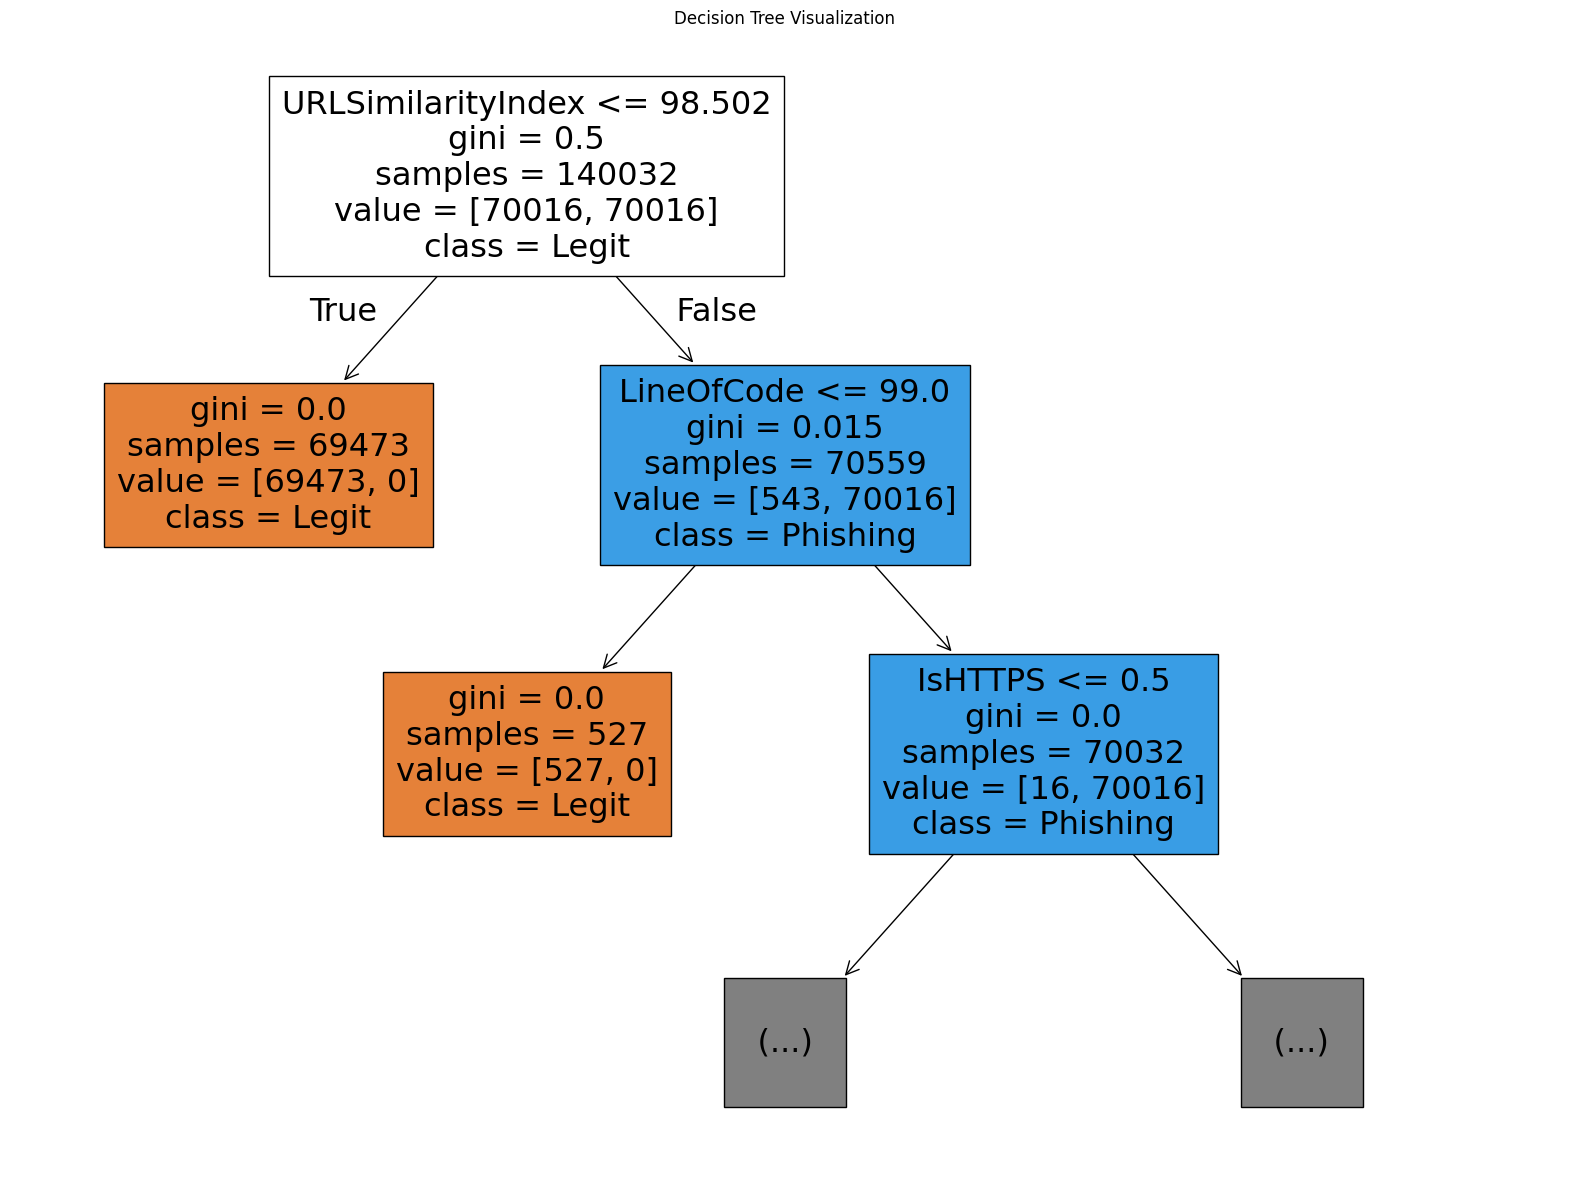

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 15))
plot_tree(DTC, feature_names=X.columns, class_names=["Legit", "Phishing"], filled=True, max_depth=2)
plt.title("Decision Tree Visualization")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, ypredict2, digits=5))

              precision    recall  f1-score   support

           0    1.00000   1.00000   1.00000     30121
           1    1.00000   1.00000   1.00000     40376

    accuracy                        1.00000     70497
   macro avg    1.00000   1.00000   1.00000     70497
weighted avg    1.00000   1.00000   1.00000     70497



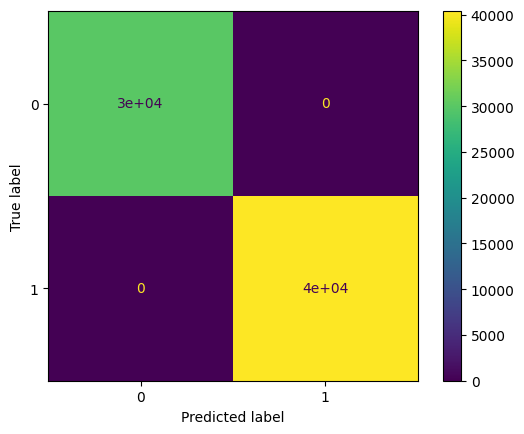

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, ypredict2)
plt.show()
# 0= legitimate        1= phishing

# XGBoost

In [ ]:
from xgboost import XGBClassifier


In [ ]:
XGB = XGBClassifier(max_depth=5, random_state=42)
XGB.fit(X_train_res, y_train_res)
 #(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
ypredict4 = XGB.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, ypredict4, digits=5))

              precision    recall  f1-score   support

           0    1.00000   1.00000   1.00000     30121
           1    1.00000   1.00000   1.00000     40376

    accuracy                        1.00000     70497
   macro avg    1.00000   1.00000   1.00000     70497
weighted avg    1.00000   1.00000   1.00000     70497



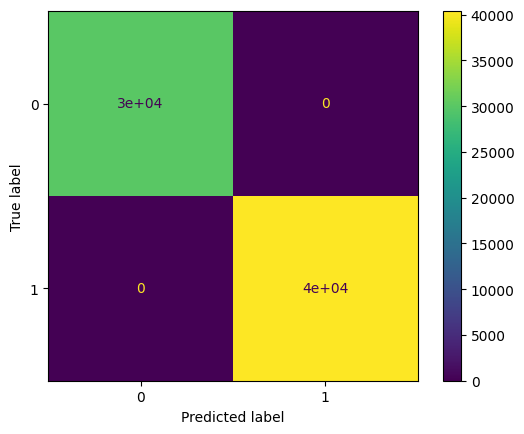

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, ypredict4)
plt.show()

# KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
KNN = KNeighborsClassifier()
KNN.fit(X_train_res, y_train_res)
 #(X_train, y_train)

KNeighborsClassifier()

In [ ]:
ypredict3 = KNN.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score
r2= r2_score(y_test, ypredict3)
print(r2)

0.9913629740076099


In [ ]:
#too many varables to plot for an easy visual

from sklearn.metrics import classification_report
print(classification_report(y_test, ypredict3, digits=5))

              precision    recall  f1-score   support

           0    0.99867   0.99638   0.99752     30121
           1    0.99730   0.99901   0.99816     40376

    accuracy                        0.99789     70497
   macro avg    0.99799   0.99770   0.99784     70497
weighted avg    0.99789   0.99789   0.99789     70497



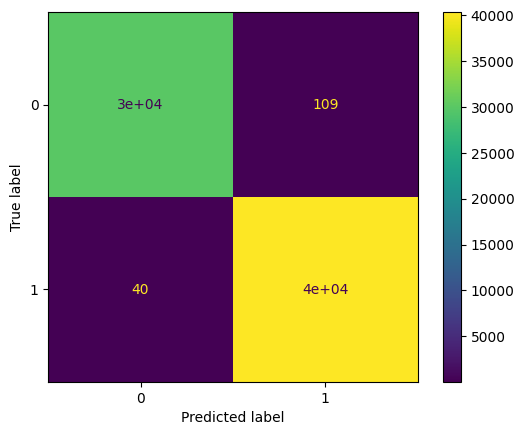

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, ypredict3)
plt.show()
# 0= legitimate        1= phishing

# CNN:

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *


In [ ]:
#reshape the data to fit in a CNN
#(X_train_res, y_train_res)
X_trainCNN= X_train_res.values.reshape(X_train_res.shape[0], X_train_res.shape[1], 1)
X_testCNN= X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

In [ ]:
classifier= Sequential()

classifier.add(Input(shape=(X_train_res.shape[1],1))) #this part added to avoid a warning

classifier.add(Conv1D(filters=32, kernel_size=3, activation='relu'))
classifier.add(MaxPooling1D(pool_size=2))

classifier.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
classifier.add(MaxPooling1D(pool_size=2))

classifier.add(Flatten())
classifier.add(Dense(128, activation='relu'))
classifier.add(Dense(units=256, activation='relu'))
classifier.add(Dense(units=1, activation='sigmoid'))


In [ ]:
#compiling it all
classifier.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
trainingCNN = classifier.fit(X_trainCNN, y_train_res, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9783 - loss: 2.5148 - val_accuracy: 0.9983 - val_loss: 0.0054
Epoch 2/10
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9946 - loss: 0.2803 - val_accuracy: 0.9979 - val_loss: 0.0103
Epoch 3/10
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9989 - loss: 0.0058 - val_accuracy: 0.9999 - val_loss: 4.2111e-04
Epoch 4/10
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9974 - loss: 0.0978 - val_accuracy: 0.9999 - val_loss: 2.9501e-04
Epoch 5/10
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9995 - loss: 0.0032 - val_accuracy: 0.9999 - val_loss: 6.8073e-04
Epoch 6/10
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9985 - loss: 0.0400 - val_accuracy: 0.9999 - val_loss: 4.4740e-04
Epoch 7/10
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9991 - loss: 0.0190 - val_accuracy: 0.9998 - val_loss: 6.0646e-04
Epoch 8/10
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accura

In [ ]:
ypredict5prob= classifier.predict(X_testCNN)
ypredict5 = (ypredict5prob>0.5).astype(int)

2204/2204 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


In [ ]:

from sklearn.metrics import classification_report
print(classification_report(y_test, ypredict5, digits=5))

              precision    recall  f1-score   support

           0    0.99993   0.99993   0.99993     30121
           1    0.99995   0.99995   0.99995     40376

    accuracy                        0.99994     70497
   macro avg    0.99994   0.99994   0.99994     70497
weighted avg    0.99994   0.99994   0.99994     70497



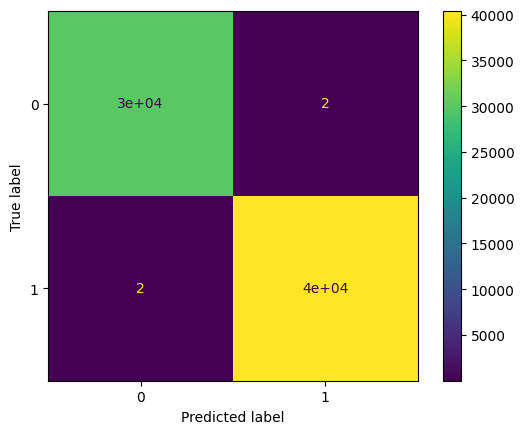

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, ypredict5)
plt.show()

# LSTM

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

In [ ]:
#train data like with CNN for the LSTM
X_trainLSTM= X_train_res.values.reshape(X_train_res.shape[0], X_train_res.shape[1], 1)
X_testLSTM= X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

In [ ]:
LSTMm= Sequential()
LSTMm.add(Input(shape=(X_train_res.shape[1],1))) #this part added to avoid a warning
LSTMm.add(LSTM(64))

LSTMm.add(Dropout(0.3))

LSTMm.add(Dense(32,activation='relu'))
LSTMm.add(Dense(1, activation='sigmoid'))

In [ ]:
LSTMm.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
trainingLSTM = LSTMm.fit(X_trainLSTM, y_train_res, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 63s 17ms/step - accuracy: 0.9921 - loss: 0.0261 - val_accuracy: 0.9826 - val_loss: 0.0582
Epoch 2/10
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 81s 17ms/step - accuracy: 0.9976 - loss: 0.0078 - val_accuracy: 0.9990 - val_loss: 0.0057
Epoch 3/10
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 60s 17ms/step - accuracy: 0.9987 - loss: 0.0041 - val_accuracy: 0.9995 - val_loss: 0.0029
Epoch 4/10
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 81s 17ms/step - accuracy: 0.9987 - loss: 0.0046 - val_accuracy: 0.9992 - val_loss: 0.0032
Epoch 5/10
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 61s 17ms/step - accuracy: 0.9993 - loss: 0.0025 - val_accuracy: 0.9994 - val_loss: 0.0014
Epoch 6/10
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 61s 17ms/step - accuracy: 0.9996 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 5.0693e-05
Epoch 7/10
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 60s 17ms/step - accuracy: 0.9997 - loss: 0.0012 - val_accuracy: 0.9995 - val_loss: 0.0020
Epoch 8/10
3501/3501 ━━━━━━━━━━━━━━━━━━━━ 60s 17ms/step - accuracy: 0.99

In [ ]:
ypredict6prob= LSTMm.predict(X_testLSTM)
ypredict6 = (ypredict6prob>0.5).astype(int)

2204/2204 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step


In [ ]:

from sklearn.metrics import classification_report
print(classification_report(y_test, ypredict6, digits=5))

              precision    recall  f1-score   support

           0    1.00000   0.99997   0.99998     30121
           1    0.99998   1.00000   0.99999     40376

    accuracy                        0.99999     70497
   macro avg    0.99999   0.99998   0.99999     70497
weighted avg    0.99999   0.99999   0.99999     70497



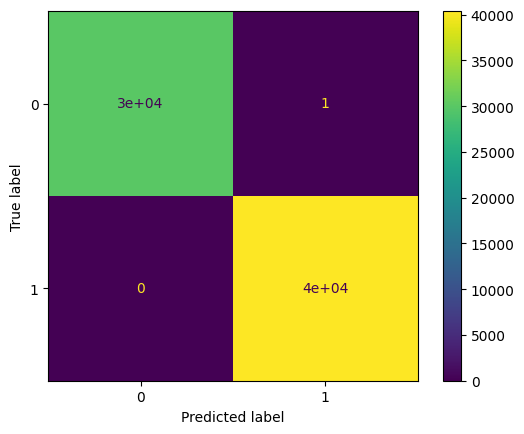

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, ypredict6)
plt.show()